In [9]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_original as ut
import EI.ei_open_loop as eol
import EI.ei_unified as eu
import EI.ei_jax as ej

from utils.logger import logger, tqdm_bar

In [2]:
plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 8,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/"
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png", dpi=300)


In [4]:
cfg_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_test.yaml")

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]
sc = cfg["scan"]
op = cfg["open_system"]

nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)

p = eu.MFPars(**md["mean_field"])

In [8]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd_ref, p, **eq["critical"])

logger.info(f"Delta_0 = {d0}")
logger.info(f"T_c     = {tc}")
logger.info(f"mu0     = {mu0}")

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[11:43:54] [INFO    ] Delta_0 = 0.4277674535851255
[11:43:54] [INFO    ] T_c     = 0.23073367729038
[11:43:54] [INFO    ] mu0     = 1.5347833443573202


In [7]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

In [37]:
# mua = np.empty(nt)

# for q in tqdm(range(nt), desc="eq. mu_B refs"):
#     sq = eu.solve_eq(bd, p, t=t1a[q], d=1.0, m=0.0, **eq["solve"])

#     mua[q] = sq.mu

#     de = sq.d
#     me = sq.m

# print(mua[1:])
# mu_B = np.mean(mua[1:])

In [38]:
bc = op["bath"]

rf = getattr(ej, bc["rate"])

bpars = dict(bc["pars"])
bpars["rate"] = rf

In [39]:
Ec = md["mean_field"]["v"] * md["mean_field"]["n"] /2 + (md["band"]["pars"]["ta"] + md["band"]["pars"]["tb"]) / (2 * (md["band"]["pars"]["ta"] - md["band"]["pars"]["tb"])) * (md["mean_field"]["v"] * s0.m - md["band"]["pars"]["gap"])
print(Ec)

bpars["mu"] = Ec

1.1205983143655023


In [40]:
da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = s0.d
me = s0.m


for j in tqdm(range(nt), desc="T2"):
    t2 = t2a[j]
    se = eu.solve_eq(bd, p, t=t2,
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1",
        leave=False,
    ):
        t1 = t1a[i]
        bs = (ej.gam_db(t=t1, name="bath 1", **bpars),
              ej.gam_db(t=t2, name="bath 2", **bpars))

        so = ej.solve_open(bd, p, n, bs, d=d, m=m, **op["solve"])

        ds = 0.1 * d0

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        #update
        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

T2: 100%|██████████| 200/200 [09:01<00:00,  2.71s/it]


In [41]:
def plot_phase_diag(da, d0, tn, config=None, OUT=None, name="phase_diag", save=False, overwrite=False):
    z = da / d0

    h=0.85
    cm = cmaps.lipari

    fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

    im = ax.pcolormesh(tn, tn, z, shading="auto", cmap=cm, vmin=0.0)
    im.set_edgecolor("face")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)
    
    #probe points
    r = np.array([x**2 for x in np.arange(cfg["ratio_sweep"]["r_min"], cfg["ratio_sweep"]["r_max"], cfg["ratio_sweep"]["r_step"])])
    ax.scatter(cfg["ratio_sweep"]["x0"] * np.sqrt(r), cfg["ratio_sweep"]["x0"] / np.sqrt(r), color="green")

    ax.set_xlabel(r"$T_1/T_c$")
    ax.set_ylabel(r"$T_2/T_c$")
    ax.set_xlim(tn.min(), tn.max())
    ax.set_ylim(tn.min(), tn.max())

    plt.tight_layout()

    if save:
        if OUT is None:
            raise ValueError("OUT must be provided when save=True")

        if config is None:
            raise ValueError("config must be provided when save=True")

        OUT = Path(OUT)
        OUT.mkdir(parents=True, exist_ok=True)

        plot_file = OUT / f"{name}.pdf"
        pars_file = OUT / f"{name}.yaml"

        if not overwrite and (plot_file.exists() or pars_file.exists()):
            raise FileExistsError(f"{name} already exists in {OUT}")

        meta = {
            "figure": plot_file.name,
            "simulation": config
        }

        txt = yaml.safe_dump(meta, sort_keys=False)
        fig.savefig(plot_file, bbox_inches="tight")
        pars_file.write_text(txt, encoding="utf-8")

        print("Saved:", plot_file)
        print("Saved:", pars_file)

        plt.show()

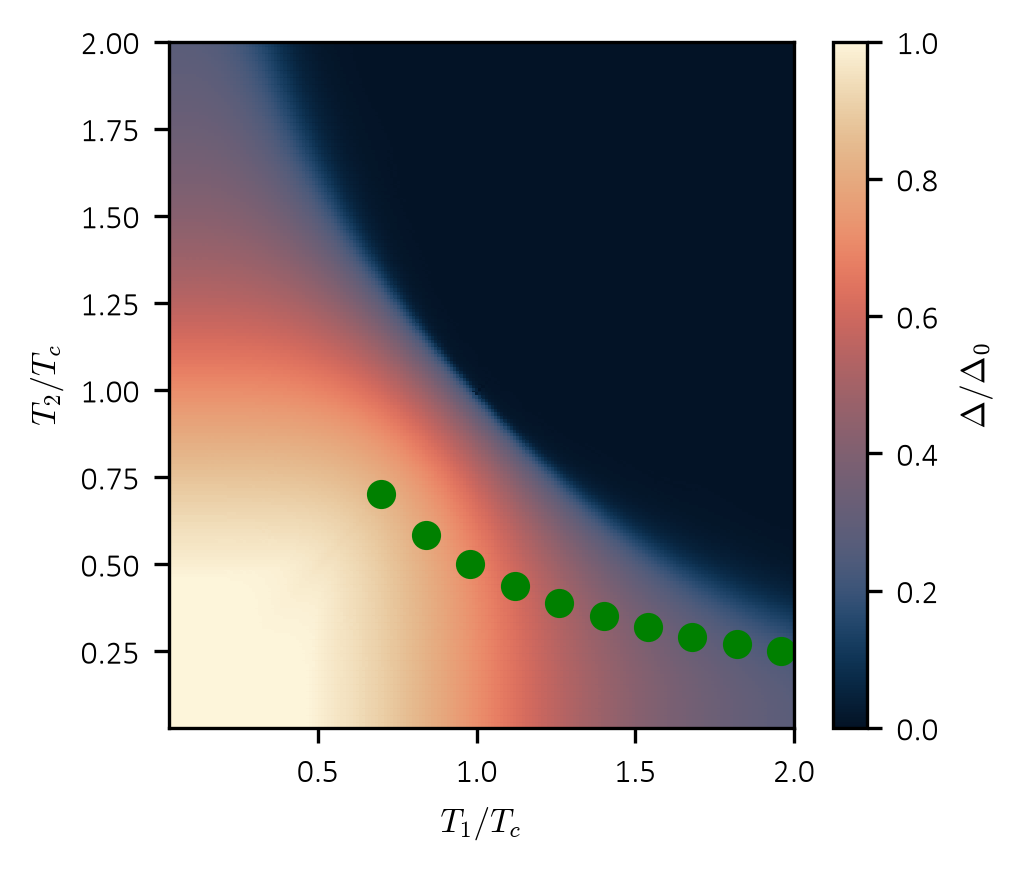

In [42]:
plot_phase_diag(da, d0, tn, config = cfg, OUT=OUT, name="phase_diag_test", save=False)

In [45]:
rs = cfg["ratio_sweep"]

x0 = rs["x0"]
r = np.arange(rs["r_min"], rs["r_max"], rs["r_step"]) ** 2
x1a = x0 * np.sqrt(r)
x2a = x0 / np.sqrt(r)

t0 = x0 * tc

band = getattr(eu, md["band"]["name"])
bd_dense = band(md["nk"]["reference"], **md["band"]["pars"])
p = eu.MFPars(**md["mean_field"])

se = eu.solve_eq(bd_dense, p, t=t0, d=max(abs(s0.d), 1.0e-4), m=s0.m, **eq["solve"])

nk1 = int(round(np.sqrt(se.n.shape[1])))

c = nk1 // 2
q = np.arange(c + 1)

i1 = c - q
j1 = np.full_like(q, c)

i2 = np.zeros(c, dtype=int)
j2 = c - np.arange(1, c + 1)

i3 = np.arange(1, c + 1)
j3 = np.arange(1, c + 1)

ii = np.concatenate((i1, i2, i3))
jj = np.concatenate((j1, j2, j3))

s1 = np.linspace(0.0, np.pi, c + 1)
s2 = np.linspace(np.pi, 2.0 * np.pi, c + 1)[1:]
s3 = np.linspace(2.0 * np.pi, (2.0 + np.sqrt(2.0)) * np.pi, c + 1)[1:]

ks = np.concatenate((s1, s2, s3))

kt = [0.0, np.pi, 2.0 * np.pi, (2.0 + np.sqrt(2.0)) * np.pi]
kl = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]


def path(n):
    n = np.asarray(n)
    na = n[0].reshape(nk1, nk1)[ii, jj]
    nb = n[1].reshape(nk1, nk1)[ii, jj]
    return na, nb


def path1(z):
    z = np.asarray(z).reshape(nk1, nk1)
    return z[ii, jj]


nea, neb = path(se.n)

gam_pars = dict(op["bath"]["pars"])
gam_pars["rate"] = getattr(ej, op["bath"]["rate"])

naa = np.empty((x2a.size, ks.size))
nba = np.empty_like(naa)
da1 = np.empty(x2a.size)
era = np.empty(x2a.size)
oka = np.empty(x2a.size, dtype=bool)

eaa = np.empty_like(naa)
eba = np.empty_like(naa)
ua = np.empty_like(naa)
va = np.empty_like(naa)

eah = np.empty_like(naa)
ebh = np.empty_like(naa)

nfa = np.empty((r.size, 2, nk1, nk1))

n = se.n.copy()
d = se.d
m = se.m

bar = tqdm(range(r.size), desc="Ratio sweep")

for q in bar:
    x1 = x1a[q]
    x2 = x2a[q]

    t1 = x1 * tc
    t2 = x2 * tc

    bs = (
        ej.gam_db(t1, name="bath 1", **gam_pars),
        ej.gam_db(t2, name="bath 2", **gam_pars),
    )

    sp = ej.solve_open(bd_dense, p, n, bs, d=d, m=m, **op["solve"])
    
    nfa[q] = np.asarray(sp.n).reshape(2, nk1, nk1)
    naa[q], nba[q] = path(sp.n)
    da1[q] = abs(sp.d)
    era[q] = sp.err
    oka[q] = sp.ok

    eaa[q], eba[q] = path(sp.st.e)
    ua[q] = path1(sp.st.u)
    va[q] = path1(sp.st.v)

    eah[q] = path1(sp.st.eah)
    ebh[q] = path1(sp.st.ebh)

    n = sp.n.copy()
    d = sp.d
    m = sp.m

    bar.set_postfix(r=f"{r[q]:.2f}", t1=f"{x1:.2f}", t2=f"{x2:.2f}", d=f"{abs(sp.d):.3e}", err=f"{sp.err:.2e}")

print("All converged:", np.all(oka))
print("Largest error:", np.max(era))

Ratio sweep: 100%|██████████| 10/10 [00:23<00:00,  2.32s/it, d=3.425e-05, err=2.52e-05, r=7.84, t1=1.96, t2=0.25]

All converged: True
Largest error: 4.738941788673401e-05


In [46]:
def plot_nalpha_beta(naa, nba, nea, neb, r, ks, kt, kl, config, OUT=None, name="nalpha_beta", save=False, overwrite=False):
    x0 = config["ratio_sweep"]["x0"]
    ra = r

    norm = Normalize(vmin=ra.min(), vmax=ra.max())
    cm = bgr_custom
    sm = ScalarMappable(norm=norm, cmap=cm)
    sm.set_array([])

    h = 1.15
    fig, ax = plt.subplots(2, 1, figsize=(3.47412, h * 3.47412), sharex=True)

    for q in tqdm(range(r.size), desc="Plotting"):
        cl = cm(norm(ra[q]))

        ax[0].plot(ks, naa[q], color=cl, linewidth=1.3)
        ax[1].plot(ks, nba[q], color=cl, linewidth=1.3)

    ax[0].plot(ks, nea, color="black", linestyle="--", linewidth=1.5, label=rf"eq, $T/T_c={x0:.1f}$")
    ax[1].plot(ks, neb, color="black", linestyle="--", linewidth=1.5, label=rf"eq, $T/T_c={x0:.1f}$")

    ax[0].set_ylabel(r"$n_{\alpha\mathbf{k}}$")
    ax[1].set_ylabel(r"$n_{\beta\mathbf{k}}$")
    ax[1].set_xlabel(r"$\mathbf{k}$")

    for a in ax:
        a.set_xlim(ks[0], ks[-1])
        a.set_xticks(kt)
        a.set_xticklabels(kl)
        a.grid(alpha=0.3)
        a.legend(loc="best", fontsize=7)

    cax = inset_axes(ax[1], width="3%", height="211%", loc="lower left",
                     bbox_to_anchor=(1.02, 0, 1, 1), bbox_transform=ax[1].transAxes, borderpad=0)

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(r"$T_1/T_2$", rotation=90, labelpad=5)

    plt.tight_layout()

    if save:
        if OUT is None:
            raise ValueError("OUT must be provided when save=True")

        OUT = Path(OUT)
        OUT.mkdir(parents=True, exist_ok=True)

        plot_file = OUT / f"{name}.pdf"
        pars_file = OUT / f"{name}.yaml"

        if not overwrite and (plot_file.exists() or pars_file.exists()):
            raise FileExistsError(f"{name} already exists in {OUT}")

        meta = {
            "figure": plot_file.name,
            "simulation": config,
        }

        txt = yaml.safe_dump(meta, sort_keys=False)
        fig.savefig(plot_file, bbox_inches="tight")
        pars_file.write_text(txt, encoding="utf-8")

        print("Saved:", plot_file)
        print("Saved:", pars_file)

    plt.show()

Plotting: 100%|██████████| 10/10 [00:00<00:00, 2674.60it/s]
/tmp/ipykernel_25859/1124106860.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


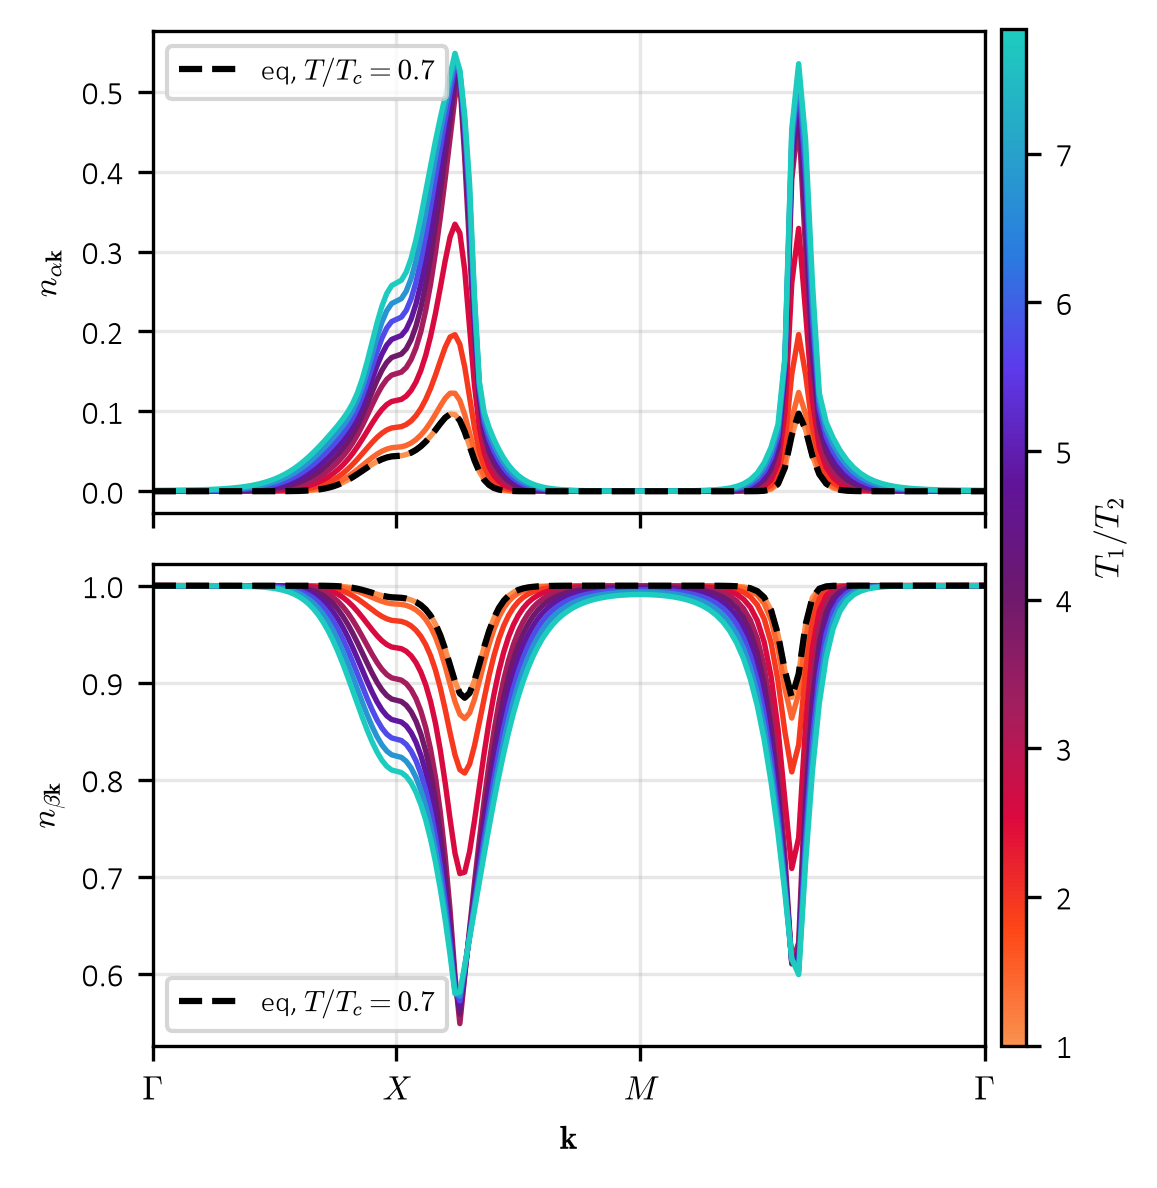

In [47]:
plot_nalpha_beta(naa, nba, nea, neb, r, ks, kt, kl,cfg, OUT=OUT, name="nalpha_beta_test", save=False, overwrite=True)

In [48]:
def plot_nalpha_beta_bz(nfa, r, q0, config, OUT=None, name="nalpha_beta_bz", save=False, overwrite=False):
    nf = nfa[q0]
    nk1 = nf.shape[-1]

    ke = np.linspace(-1.0, 1.0, nk1 + 1)

    h = 0.62
    fig, ax = plt.subplots(1, 2, figsize=(3.47412, h * 3.47412), sharex=True, sharey=True)

    im0 = ax[0].pcolormesh(ke, ke, nf[0].T, shading="flat", cmap=cmaps.lipari, vmin=0.0, vmax=1.0)
    im0.set_edgecolor("face")

    im1 = ax[1].pcolormesh(ke, ke, nf[1].T, shading="flat", cmap=cmaps.lipari, vmin=0.0, vmax=1.0)
    im1.set_edgecolor("face")

    ax[0].text(0.05, 0.93, r"$n_{\alpha\mathbf{k}}$", transform=ax[0].transAxes,
               color="white", ha="left", va="top")

    ax[1].text(0.05, 0.93, r"$n_{\beta\mathbf{k}}$", transform=ax[1].transAxes,
               color="k", ha="left", va="top")

    ax[1].text(0.95, 0.93, rf"$T_1/T_2={r[q0]:.2f}$", transform=ax[1].transAxes,
               color="k", ha="right", va="top")
    ax[0].tick_params(which="both", direction="in")
    ax[1].tick_params(which="both", direction="in")

    for a in ax:
        a.set_xlim(ke[0], ke[-1])
        a.set_ylim(ke[0], ke[-1])
        a.set_aspect("equal")
        a.set_xlabel(r"$k_x/\pi$")

    ax[0].set_ylabel(r"$k_y/\pi$")

    cax = inset_axes(ax[1], width="3%", height="100%", loc="lower left",
                     bbox_to_anchor=(1.02, 0, 1, 1), bbox_transform=ax[1].transAxes, borderpad=0)

    cbar = fig.colorbar(im1, cax=cax)
    cbar.set_label(r"$n_{\lambda\mathbf{k}}$", rotation=90, labelpad=5)

    plt.tight_layout()

    if save:
        if OUT is None:
            raise ValueError("OUT must be provided when save=True")

        OUT = Path(OUT)
        OUT.mkdir(parents=True, exist_ok=True)

        plot_file = OUT / f"{name}.pdf"
        pars_file = OUT / f"{name}.yaml"

        if not overwrite and (plot_file.exists() or pars_file.exists()):
            raise FileExistsError(f"{name} already exists in {OUT}")

        meta = {
            "figure": plot_file.name,
            "plot": {
                "q0": int(q0),
                "ratio": float(r[q0]),
            },
            "simulation": config,
        }

        txt = yaml.safe_dump(meta, sort_keys=False)
        fig.savefig(plot_file, bbox_inches="tight")
        pars_file.write_text(txt, encoding="utf-8")

        print("Saved:", plot_file)
        print("Saved:", pars_file)

    plt.show()

/tmp/ipykernel_25859/2499714608.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


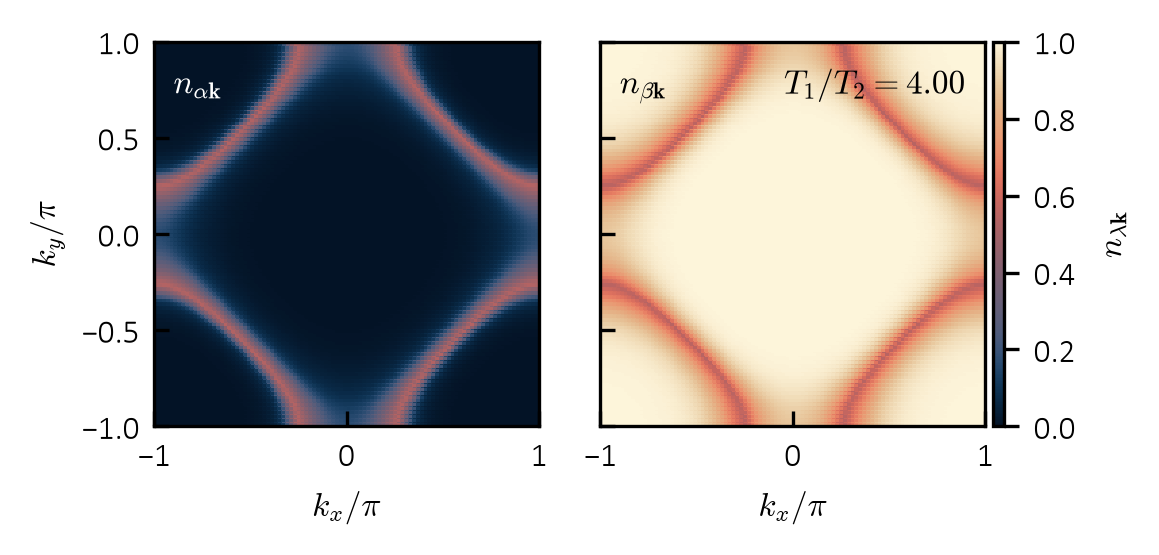

In [49]:
q0 = 5

plot_nalpha_beta_bz(nfa, r, q0, cfg, OUT=OUT, name="nalpha_beta_bz_q3", save=False, overwrite=True)

In [50]:
Ec = md["mean_field"]["v"] * md["mean_field"]["n"] /2 + (md["band"]["pars"]["ta"] + md["band"]["pars"]["tb"]) / (2 * (md["band"]["pars"]["ta"] - md["band"]["pars"]["tb"])) * (md["mean_field"]["v"] * s0.m - md["band"]["pars"]["gap"])

In [51]:
def plot_energies_uv(eaa, eba, ua, va, eah, ebh, ra, ks, kt, kl, config, OUT=None, name="energies_uv", save=False, overwrite=False):
    norm = Normalize(vmin=ra.min(), vmax=ra.max())
    cm = bgr_custom
    sm = ScalarMappable(norm=norm, cmap=cm)
    sm.set_array([])

    h = 1.15
    fig, ax = plt.subplots(2, 1, figsize=(3.47412, h * 3.47412), sharex=True)

    for q in tqdm(range(ra.size), desc="Plotting"):
        cl = cm(norm(ra[q]))

        ax[0].plot(ks, eaa[q], color=cl, linestyle="-", linewidth=1.2)
        ax[0].plot(ks, eba[q], color=cl, linestyle="--", linewidth=1.2)

        ax[1].plot(ks, ua[q], color=cl, linestyle="-", linewidth=1.2)
        ax[1].plot(ks, va[q], color=cl, linestyle="--", linewidth=1.2)

    ax[0].plot(ks, eah[0], color="black", linestyle="-", linewidth=0.5)
    ax[0].plot(ks, ebh[0], color="black", linestyle="-", linewidth=0.5)

    ax[0].plot([], [], color="black", linestyle="-", label=r"$E_{\alpha\mathbf{k}}$")
    ax[0].plot([], [], color="black", linestyle="--", label=r"$E_{\beta\mathbf{k}}$")

    ax[1].plot([], [], color="black", linestyle="-", label=r"$u_{\mathbf{k}}$")
    ax[1].plot([], [], color="black", linestyle="--", label=r"$v_{\mathbf{k}}$")

    ax[0].set_ylabel(r"$E_{\lambda\mathbf{k}}/|t_a|$")
    ax[1].set_ylabel(r"$u_{\mathbf{k}},\,v_{\mathbf{k}}$")
    ax[1].set_xlabel(r"$\mathbf{k}$")

    ax[0].tick_params(which="both", direction="in")
    ax[1].tick_params(which="both", direction="in")
    ax[0].axhline(Ec, ks[0], ks[-1], color="k", ls="-.", lw=0.5)

    for a in ax:
        a.set_xlim(ks[0], ks[-1])
        a.set_xticks(kt)
        a.set_xticklabels(kl)
        a.grid(alpha=0.3)
        a.legend(loc="best", ncol=2, fontsize=8)

    cax = inset_axes(ax[1], width="3%", height="208%", loc="lower left",
                     bbox_to_anchor=(1.02, 0, 1, 1), bbox_transform=ax[1].transAxes, borderpad=0)

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(r"$T_1/T_2$", rotation=90, labelpad=5)

    plt.tight_layout()

    if save:
        if OUT is None:
            raise ValueError("OUT must be provided when save=True")

        OUT = Path(OUT)
        OUT.mkdir(parents=True, exist_ok=True)

        plot_file = OUT / f"{name}.pdf"
        pars_file = OUT / f"{name}.yaml"

        if not overwrite and (plot_file.exists() or pars_file.exists()):
            raise FileExistsError(f"{name} already exists in {OUT}")

        meta = {
            "figure": plot_file.name,
            "simulation": config,
        }

        txt = yaml.safe_dump(meta, sort_keys=False)
        fig.savefig(plot_file, bbox_inches="tight")
        pars_file.write_text(txt, encoding="utf-8")


        print("Saved:", plot_file)
        print("Saved:", pars_file)

    plt.show()

Plotting: 100%|██████████| 10/10 [00:00<00:00, 1389.16it/s]
/tmp/ipykernel_25859/1100404195.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


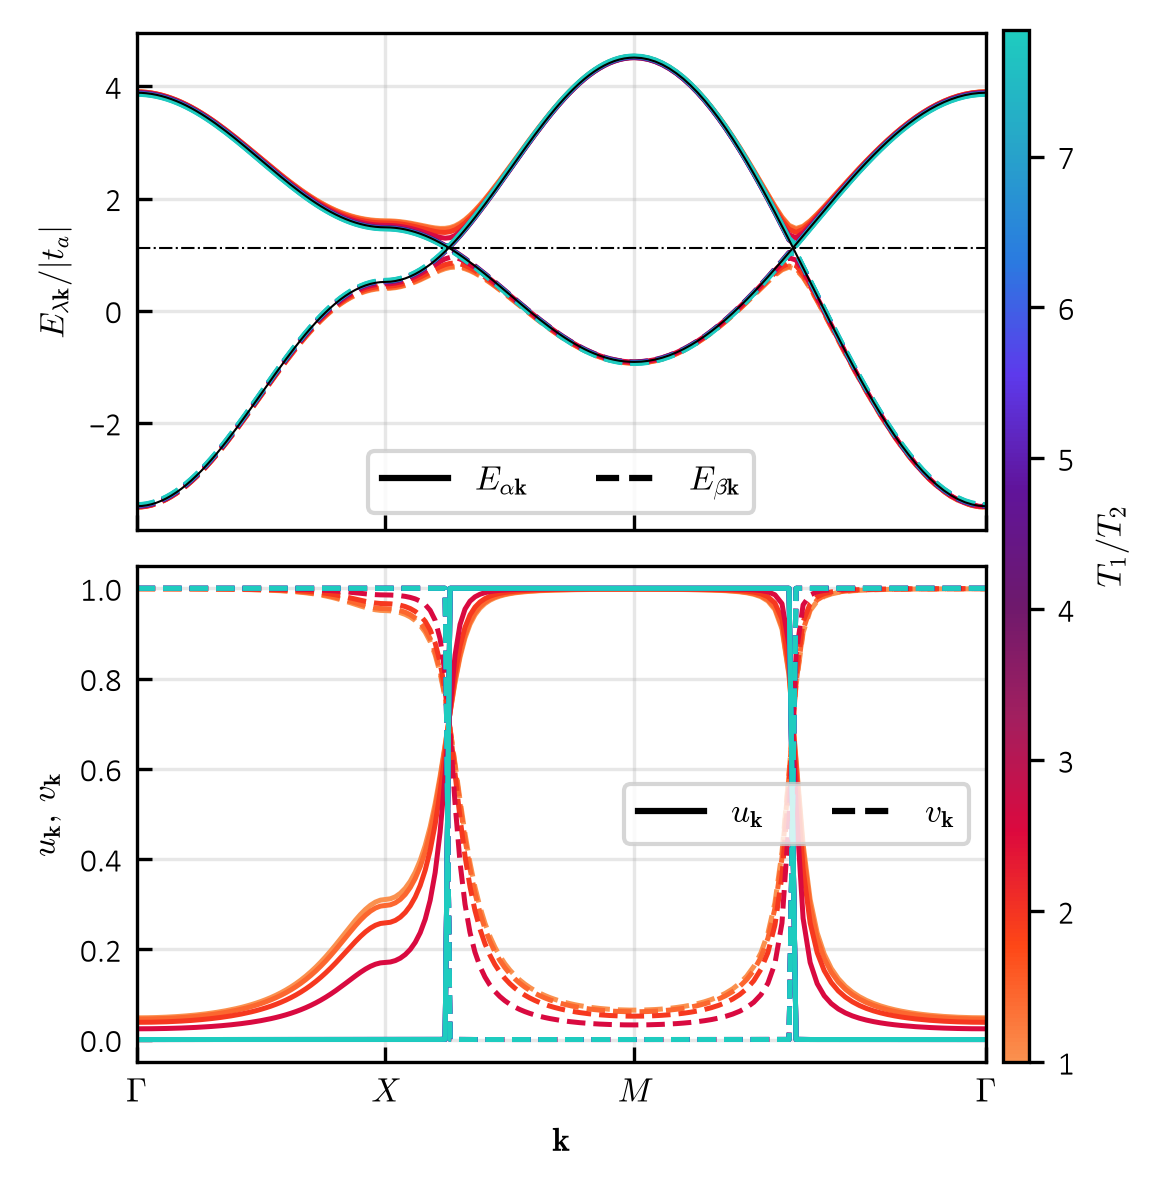

In [52]:
ra = r

plot_energies_uv(eaa, eba, ua, va, eah, ebh, ra, ks, kt, kl, cfg,
                 OUT=OUT, name="energies_uv_b2", save=False, overwrite=True)

In [ ]:
# x0 = 0.7
# r = np.arange(1.0, 3.0, 0.2) ** 2
# x1a = x0 * np.sqrt(r)
# x2a = x0 / np.sqrt(r)

# t0 = x0 * tc

# bd_dense = eu.tb_2d(cfg["nk_sparse"], **cfg["tb_2d"])

# se = eu.solve_eq(bd_dense, p, t=t0, d=max(abs(s0.d), 1.0e-4), m=s0.m, mix=(0.15, 0.15), tol=1.0e-9, nmax=20000, chk=20, prog=True)

# nk1 = int(round(np.sqrt(se.n.shape[1])))

# c = nk1 // 2
# q = np.arange(c + 1)

# i1 = c - q
# j1 = np.full_like(q, c)

# i2 = np.zeros(c, dtype=int)
# j2 = c - np.arange(1, c + 1)

# i3 = np.arange(1, c + 1)
# j3 = np.arange(1, c + 1)

# ii = np.concatenate((i1, i2, i3))
# jj = np.concatenate((j1, j2, j3))

# s1 = np.linspace(0.0, np.pi, c + 1)
# s2 = np.linspace(np.pi, 2.0 * np.pi, c + 1)[1:]
# s3 = np.linspace(
#     2.0 * np.pi,
#     (2.0 + np.sqrt(2.0)) * np.pi,
#     c + 1,
# )[1:]

# ks = np.concatenate((s1, s2, s3))

# kt = [
#     0.0,
#     np.pi,
#     2.0 * np.pi,
#     (2.0 + np.sqrt(2.0)) * np.pi,
# ]

# kl = [
#     r"$\Gamma$",
#     r"$X$",
#     r"$M$",
#     r"$\Gamma$",
# ]


# def path(n):
#     n = np.asarray(n)
#     na = n[0].reshape(nk1, nk1)[ii, jj]
#     nb = n[1].reshape(nk1, nk1)[ii, jj]
#     return na, nb


# nea, neb = path(se.n)

# kaa = 0.3
# kab = 0.6
# kbb = 0.3
# wc = np.inf

# # Output arrays
# naa = np.empty((x2a.size, ks.size))
# nba = np.empty_like(naa)
# da1 = np.empty(x2a.size)
# era = np.empty(x2a.size)
# oka = np.empty(x2a.size, dtype=bool)

# eaa = np.empty_like(naa)
# eba = np.empty_like(naa)
# ua = np.empty_like(naa)
# va = np.empty_like(naa)

# eah = np.empty_like(naa)
# ebh = np.empty_like(naa)

# def path1(z):
#     z = np.asarray(z).reshape(nk1, nk1)
#     return z[ii, jj]


# n = se.n.copy()
# d = se.d
# m = se.m

# bar = tqdm(range(r.size), desc="Ratio sweep")

# for q in bar:
#     x1 = x1a[q]
#     x2 = x2a[q]

#     t1 = x1 * tc
#     t2 = x2 * tc
    
#     bs = (
#         ej.gam_db(
#             t1,
#             kap=(kaa, kab, kbb),
#             wc=wc,
#             mu=mu_B,
#             name="bath 1",
#             rate=ej.rate_product,
#         ),
#         ej.gam_db(
#             t2,
#             kap=(kaa, kab, kbb),
#             wc=wc,
#             mu=mu_B,
#             name="bath 2",
#             rate=ej.rate_product,
#         ),
#     )

#     sp = ej.solve_open(
#         bd_dense,
#         p,
#         n,
#         bs,
#         d=d,
#         m=m,
#         dt=0.8,
#         td=0.3,
#         tm=0.3,
#         tol=1.0e-5,
#         nmax=20000,
#         chk=20,
#         prog=False,
#     )

#     naa[q], nba[q] = path(sp.n)
#     da1[q] = abs(sp.d)
#     era[q] = sp.err
#     oka[q] = sp.ok
    
#     eaa[q], eba[q] = path(sp.st.e)
#     ua[q] = path1(sp.st.u)
#     va[q] = path1(sp.st.v)

#     eah[q] = path1(sp.st.eah)
#     ebh[q] = path1(sp.st.ebh)

#     n = sp.n.copy()
#     d = sp.d
#     m = sp.m

#     bar.set_postfix(
#         r=f"{r[q]:.2f}",
#         t1=f"{x1:.2f}",
#         t2=f"{x2:.2f}",
#         d=f"{abs(sp.d):.3e}",
#         err=f"{sp.err:.2e}",
#     )

# print("All converged:", np.all(oka))
# print("Largest error:", np.max(era))

In [ ]:
# print("ks: ", ks.shape)
# print("eaa:", eaa.shape)
# print("eba:", eba.shape)
# print("ua: ", ua.shape)
# print("va: ", va.shape)

In [ ]:
# ra = r

# norm = Normalize(vmin=ra.min(), vmax=ra.max())
# cm = bgr_custom
# sm = ScalarMappable(norm=norm, cmap=cm)
# sm.set_array([])

# h = 1.15
# fig, ax = plt.subplots(
#     2,
#     1,
#     figsize=(3.47412, h * 3.47412),
#     sharex=True,
# )

# for q in tqdm(range(x2a.size), desc="Plotting"):
#     cl = cm(norm(ra[q]))

#     ax[0].plot(
#         ks,
#         naa[q],
#         color=cl,
#         linewidth=1.3,
#     )

#     ax[1].plot(
#         ks,
#         nba[q],
#         color=cl,
#         linewidth=1.3,
#     )

# ax[0].plot(
#     ks,
#     nea,
#     color="black",
#     linestyle="--",
#     linewidth=1.5,
#     label=rf"eq, $T/T_c={x0:.1f}$",
# )

# ax[1].plot(
#     ks,
#     neb,
#     color="black",
#     linestyle="--",
#     linewidth=1.5,
#     label=rf"eq, $T/T_c={x0:.1f}$",
# )

# ax[0].set_ylabel(r"$n_{\alpha\mathbf{k}}$")
# ax[1].set_ylabel(r"$n_{\beta\mathbf{k}}$")
# ax[1].set_xlabel(r"$\mathbf{k}$")

# for a in ax:
#     a.set_xlim(ks[0], ks[-1])
#     a.set_xticks(kt)
#     a.set_xticklabels(kl)
#     a.grid(alpha=0.3)
#     a.legend(loc="best", fontsize=7)


# cax = inset_axes(
#     ax[1],
#     width="3%",  # Makes the colorbar thin
#     height="220%",  # Adjusts height to span both subplots
#     loc="lower left",
#     bbox_to_anchor=(1.02, 0, 1, 1),
#     bbox_transform=ax[1].transAxes,
#     borderpad=0,
# )

# cbar = fig.colorbar(sm, cax=cax)
# cbar.set_label(r"$T_1/T_2$", rotation=90, labelpad=5)

# # plt.savefig(OUT+"nalpha_beta_b2.pdf", bbox_inches="tight")
# plt.show()

In [ ]:
# q0 = 3

# nf = np.asarray(sp.n).reshape(2, nk1, nk1)

# # Cell edges over the full Brillouin zone
# ke = np.linspace(-1.0, 1.0, nk1 + 1)

# h = 0.62
# fig, ax = plt.subplots(
#     1,
#     2,
#     figsize=(3.47412, h * 3.47412),
#     sharex=True,
#     sharey=True,
# )

# im0 = ax[0].pcolormesh(
#     ke,
#     ke,
#     nf[0].T,
#     shading="flat",
#     cmap=cmaps.lipari,
#     vmin=0.0,
#     vmax=1.0,
# )
# im0.set_edgecolor("face")

# im1 = ax[1].pcolormesh(
#     ke,
#     ke,
#     nf[1].T,
#     shading="flat",
#     cmap=cmaps.lipari,
#     vmin=0.0,
#     vmax=1.0,
# )
# im1.set_edgecolor("face")

# ax[0].text(
#     0.05,
#     0.93,
#     r"$n_{\alpha\mathbf{k}}$",
#     transform=ax[0].transAxes,
#     color="white",
#     ha="left",
#     va="top",
# )

# ax[1].text(
#     0.05,
#     0.93,
#     r"$n_{\beta\mathbf{k}}$",
#     transform=ax[1].transAxes,
#     color="white",
#     ha="left",
#     va="top",
# )

# ax[1].text(
#     0.95,
#     0.93,
#     rf"$T_1/T_2={r[q0]:.2f}$",
#     transform=ax[1].transAxes,
#     color="white",
#     ha="right",
#     va="top",
# )

# for a in ax:
#     a.set_xlim(ke[0], ke[-1])
#     a.set_ylim(ke[0], ke[-1])
#     a.set_aspect("equal")
#     a.set_xlabel(r"$k_x/\pi$")

# ax[0].set_ylabel(r"$k_y/\pi$")

# cax = inset_axes(
#     ax[1],
#     width="3%",  # Makes the colorbar thin
#     height="100%",  # Adjusts height to span both subplots
#     loc="lower left",
#     bbox_to_anchor=(1.02, 0, 1, 1),
#     bbox_transform=ax[1].transAxes,
#     borderpad=0,
# )

# cbar = plt.colorbar(
#     im1,
#     cax=cax,
#     fraction=0.046,
#     pad=0.04,
# )
# cbar.set_label(
#     r"$n_{\lambda\mathbf{k}}$",
#     rotation=90,
#     labelpad=5,
# )

# plt.tight_layout()
# plt.show()

In [ ]:
# norm = Normalize(vmin=ra.min(), vmax=ra.max())
# cm = bgr_custom
# sm = ScalarMappable(norm=norm, cmap=cm)
# sm.set_array([])

# h = 1.15
# fig, ax = plt.subplots(
#     2,
#     1,
#     figsize=(3.47412, h * 3.47412),
#     sharex=True,
# )

# for q in tqdm(range(ra.size), desc="Plotting"):
#     cl = cm(norm(ra[q]))

#     ax[0].plot(ks, eaa[q], color=cl, linestyle="-", linewidth=1.2)

#     ax[0].plot(ks, eba[q], color=cl, linestyle="--", linewidth=1.2,)

#     ax[0].plot(ks, eah[0], color="k", linestyle="-", linewidth=0.5,)

#     ax[0].plot(
#         ks,
#         ebh[0],
#         color="k",
#         linestyle="-",
#         linewidth=0.5,
#     )
    
#     ax[1].plot(
#         ks,
#         ua[q],
#         color=cl,
#         linestyle="-",
#         linewidth=1.2,
#     )

#     ax[1].plot(
#         ks,
#         va[q],
#         color=cl,
#         linestyle="--",
#         linewidth=1.2,
#     )

#     # ax[1].plot(
#     #     ks,
#     #     va[q] ** 2 + ua[q] ** 2,
#     #     color=cl,
#     #     linestyle="--",
#     #     linewidth=1.2,
#     # )

# # Line-style legends
# ax[0].plot(
#     [],
#     [],
#     color="black",
#     linestyle="-",
#     label=r"$E_{\alpha\mathbf{k}}$",
# )

# ax[0].plot(
#     [],
#     [],
#     color="black",
#     linestyle="--",
#     label=r"$E_{\beta\mathbf{k}}$",
# )

# ax[1].plot(
#     [],
#     [],
#     color="black",
#     linestyle="-",
#     label=r"$u_{\mathbf{k}}$",
# )

# ax[1].plot(
#     [],
#     [],
#     color="black",
#     linestyle="--",
#     label=r"$v_{\mathbf{k}}$",
# )

# ax[0].set_ylabel(r"$E_{\lambda\mathbf{k}}/|t_a|$")
# ax[1].set_ylabel(r"$u_{\mathbf{k}},\,v_{\mathbf{k}}$")
# ax[1].set_xlabel(r"$\mathbf{k}$")

# for a in ax:
#     a.set_xlim(ks[0], ks[-1])
#     a.set_xticks(kt)
#     a.set_xticklabels(kl)
#     a.grid(alpha=0.3)
#     a.legend(loc="best", ncol=2, fontsize=8)

# cax = inset_axes(
#     ax[1],
#     width="3%",  # Makes the colorbar thin
#     height="220%",  # Adjusts height to span both subplots
#     loc="lower left",
#     bbox_to_anchor=(1.02, 0, 1, 1),
#     bbox_transform=ax[1].transAxes,
#     borderpad=0,
# )

# cbar = fig.colorbar(sm, cax=cax)
# cbar.set_label(r"$T_1/T_2$", rotation=90, labelpad=5)

# plt.show()